# Chapter 4, Example 3: Exact Conditional Generation by Decimation

The chain rule writes any joint distribution as

$$
p(x_1,\ldots,x_N)=\prod_{t=1}^N p(x_{\pi_t}\mid x_{\pi_1},\ldots,x_{\pi_{t-1}}),
$$

for any ordering $\pi$. If every conditional probability can be computed exactly, sampling sequentially from these conditionals produces an exact independent sample. This procedure is called **decimation**, **sequential conditional sampling**, or, in directed models, **ancestral sampling**.

The notebook uses the four-spin chain from Chapter 2 and compares several variable orders. The final law is independent of the order, although the computational cost of obtaining conditionals may depend strongly on the order for larger graphical models.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch04":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch04").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch04"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.2,
})

DARK_NODE = "#315a78"
FACTOR_NODE = "#6b4c7a"


def save_figure(fig, stem: str) -> None:
    """Save a Matplotlib figure as both vector PDF and high-resolution PNG."""
    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=240, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def annotate_heatmap(ax, image, matrix, fmt=".2f"):
    """Use white text on dark cells and black text on light cells."""
    norm = image.norm
    cmap = image.cmap
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            rgba = cmap(norm(matrix[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            color = "black" if luminance > 0.58 else "white"
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center",
                    color=color, fontsize=12, fontweight="bold")


# The same four-spin chain used in Chapter 2.
STATES = np.array(list(product([-1, 1], repeat=4)), dtype=int)
TRUE = {
    "h": np.array([0.35, -0.15, 0.20, -0.30]),
    "J": np.array([0.85, -0.55, 0.70]),
}


def energy(states, h=TRUE["h"], J=TRUE["J"]):
    states = np.atleast_2d(states)
    unary = -(states @ h)
    pair = -(J[0] * states[:, 0] * states[:, 1]
             + J[1] * states[:, 1] * states[:, 2]
             + J[2] * states[:, 2] * states[:, 3])
    return unary + pair


def distribution_at_temperature(T=1.0, h=TRUE["h"], J=TRUE["J"]):
    E = energy(STATES, h=h, J=J)
    shifted = -(E - E.min()) / T
    weights = np.exp(shifted)
    p = weights / weights.sum()
    logZ = -E.min() / T + np.log(weights.sum())
    return p, E, logZ


def label_state(x):
    return "(" + ",".join("+" if v == 1 else "-" for v in x) + ")"

## 1. Exact conditional probabilities

For a partial assignment, the conditional distribution of the next variable is computed by summing the joint probability over all states consistent with the assignment. This is an inference oracle implemented here by enumeration.

In [2]:
p_exact, E, _ = distribution_at_temperature(T=1.0)


CONDITIONAL_CACHE = {}

def conditional_probability(variable, assignment):
    key = (variable, tuple(sorted(assignment.items())))
    if key in CONDITIONAL_CACHE:
        return CONDITIONAL_CACHE[key].copy()
    compatible = np.ones(len(STATES), dtype=bool)
    for j, value in assignment.items():
        compatible &= STATES[:, j] == value
    denom = p_exact[compatible].sum()
    probs = []
    for value in (-1, 1):
        mask = compatible & (STATES[:, variable] == value)
        probs.append(p_exact[mask].sum() / denom)
    result = np.array(probs)
    CONDITIONAL_CACHE[key] = result
    return result.copy()

print("P(x1 | no evidence) =", conditional_probability(0, {}))
print("P(x2 | x1=+1) =", conditional_probability(1, {0:1}))
assert np.isclose(conditional_probability(0,{0:1})[1], 1.0)

P(x1 | no evidence) = [0.38262896 0.61737104]
P(x2 | x1=+1) = [0.20134754 0.79865246]


## 2. The decimation algorithm

Fresh random numbers are used for every generated path. Repeating the algorithm therefore gives independent samples, not a Markov chain.

In [3]:
def decimation_sample(order, rng=RNG):
    assignment = {}
    for variable in order:
        probs = conditional_probability(variable, assignment)
        value = rng.choice([-1,1], p=probs)
        assignment[variable] = int(value)
    return np.array([assignment[i] for i in range(4)], dtype=int)

orders = {
    "left to right": [0,1,2,3],
    "right to left": [3,2,1,0],
    "outside inward": [0,3,1,2],
}
for name, order in orders.items():
    print(name, label_state(decimation_sample(order)))

left to right (+,-,+,-)
right to left (+,+,-,-)
outside inward (+,+,-,-)


## 3. A decision tree for the first two variables

The figure shows the first two levels for the left-to-right order. Every node records a partial assignment; outgoing edge labels are exact conditional probabilities. Node labels are white on dark backgrounds for book-scale readability.

Saved: figs/ch04_03_decimation_tree.pdf
Saved: figs/ch04_03_decimation_tree.png


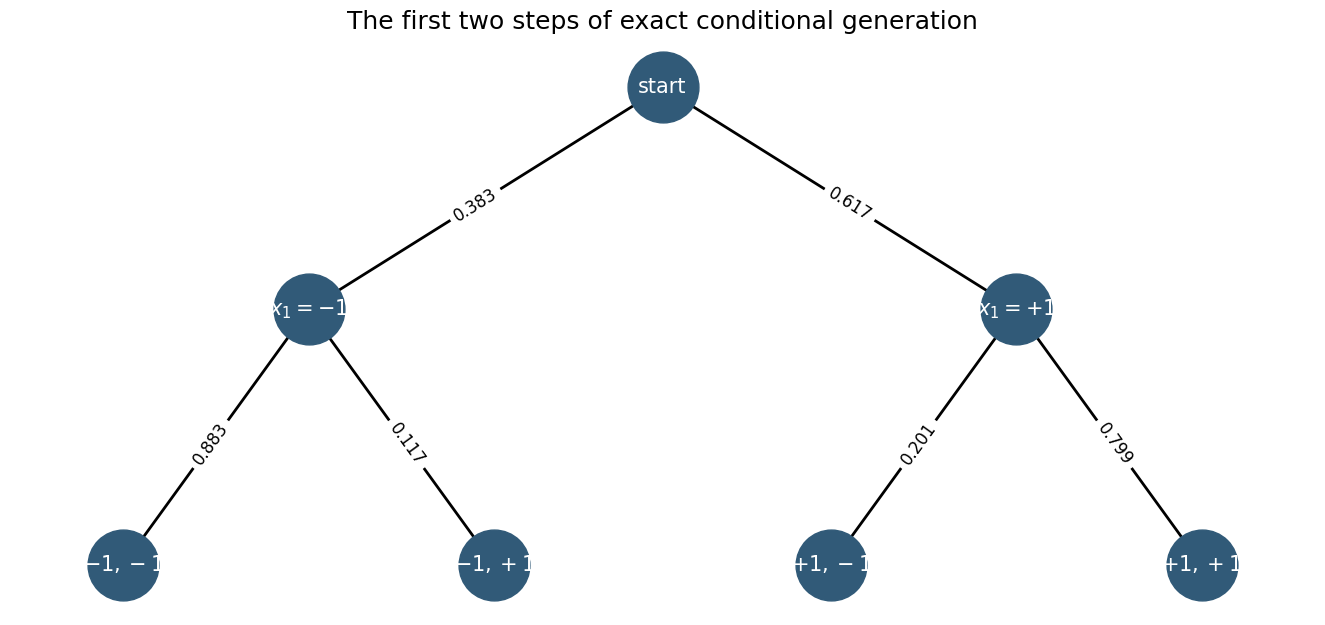

In [4]:
G = nx.DiGraph()
root = "start"
G.add_node(root, label="start")
positions = {root:(0,0)}
labels = {root:"start"}
edge_labels = {}
for k, x1 in enumerate([-1,1]):
    n1=f"x1={x1}"
    G.add_edge(root,n1)
    positions[n1]=(-2.1+4.2*k,-1.3)
    labels[n1]=rf"$x_1={x1:+d}$"
    edge_labels[(root,n1)] = f"{conditional_probability(0,{})[k]:.3f}"
    for m, x2 in enumerate([-1,1]):
        n2=f"x1={x1},x2={x2}"
        G.add_edge(n1,n2)
        positions[n2]=(-3.2+2.2*m+4.2*k,-2.8)
        labels[n2]=rf"$({x1:+d},{x2:+d})$"
        edge_labels[(n1,n2)] = f"{conditional_probability(1,{0:x1})[m]:.3f}"

fig, ax = plt.subplots(figsize=(13.5,6.5))
nx.draw_networkx_edges(G,positions,arrows=True,arrowsize=22,width=2,ax=ax)
nx.draw_networkx_nodes(G,positions,node_color=DARK_NODE,node_size=2600,ax=ax)
nx.draw_networkx_labels(G,positions,labels=labels,font_color="white",font_size=15,ax=ax)
nx.draw_networkx_edge_labels(G,positions,edge_labels=edge_labels,font_size=12,label_pos=0.53,ax=ax)
ax.set_title("The first two steps of exact conditional generation")
ax.axis("off")
fig.tight_layout()
save_figure(fig,"ch04_03_decimation_tree")
plt.show()

## 4. Sampling accuracy and order invariance

We compare empirical distributions to the exact law using total variation distance. Differences among orders are finite-sample fluctuations; all orders converge to the same target distribution.

Saved: figs/ch04_03_sampling_order_accuracy.pdf
Saved: figs/ch04_03_sampling_order_accuracy.png


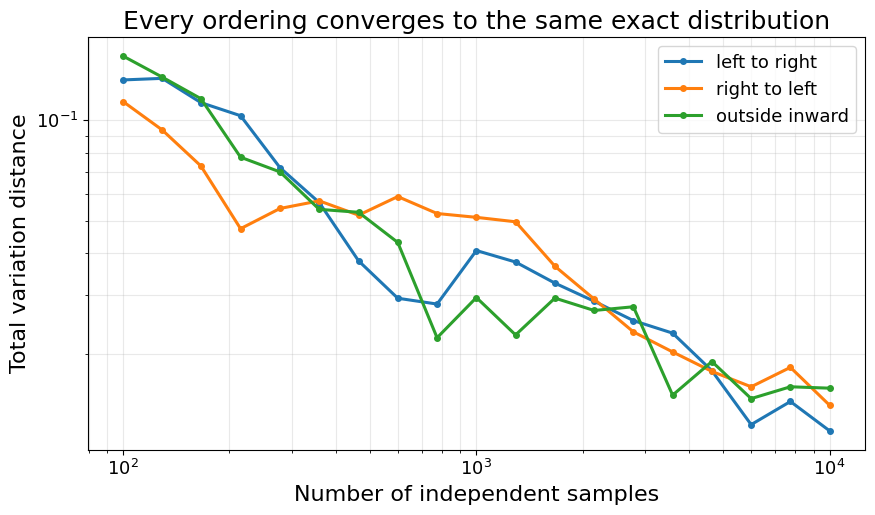

In [5]:
state_to_index = {tuple(x):i for i,x in enumerate(STATES)}
sample_sizes = np.unique(np.logspace(2,4,19).astype(int))
errors = {name:[] for name in orders}
for name, order in orders.items():
    samples = np.array([decimation_sample(order) for _ in range(sample_sizes[-1])])
    indices = np.array([state_to_index[tuple(x)] for x in samples])
    for size in sample_sizes:
        empirical = np.bincount(indices[:size], minlength=len(STATES)) / size
        errors[name].append(0.5*np.abs(empirical-p_exact).sum())

fig, ax = plt.subplots(figsize=(9,5.4))
for name, values in errors.items():
    ax.loglog(sample_sizes, values, marker="o", markersize=4, label=name)
ax.set_xlabel("Number of independent samples")
ax.set_ylabel("Total variation distance")
ax.set_title("Every ordering converges to the same exact distribution")
ax.legend()
ax.grid(True,which="both",alpha=0.28)
fig.tight_layout()
save_figure(fig,"ch04_03_sampling_order_accuracy")
plt.show()

## 5. Comparison with MCMC

Decimation produces independent draws because each run starts afresh and uses exact conditionals. MCMC instead constructs a dependent trajectory whose stationary distribution is the target law. MCMC may be much cheaper per update, but its effective number of independent samples depends on mixing and autocorrelation.

## Exercises

1. Add hard evidence $x_4=+1$ and generate exact conditional samples from the posterior.
2. Cache repeated conditional computations and compare the number of oracle calls across variable orders.
3. Implement a single-site Gibbs sampler for the same chain and compare empirical error at equal numbers of conditional evaluations.
4. Replace enumeration by sum-product messages on the tree and verify that the generated samples are unchanged.